# Task 3.1 — Zero-Shot Classification on STL-10 with CLIP

In this notebook, we:
1. Load the **STL-10** dataset (10 classes, 8,000 test images at 96×96).
2. Load OpenAI’s **CLIP ViT-B/32** model via `open_clip`.
3. Evaluate **zero-shot classification accuracy** on the complete STL-10 test set using **four distinct prompting strategies**:
   - **Plain labels** — e.g., `"cat"`
   - **Template prompts** — e.g., `"a photo of a cat."`
   - **Descriptive prompts** — e.g., `"a centered, high-resolution photograph of a cat, captured in natural lighting."`
   - **Prompt ensemble** — averaging embeddings across 7 template variants per class
4. Visualise **per-class accuracy heatmaps**, **confusion matrices**, and **sample prediction grids** for interpretability.
5. Discuss why prompt engineering matters for contrastive vision-language models.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision
from PIL import Image

from task3_clip.src.zeroshot import load_clip_model, evaluate_zeroshot, build_prompts, load_stl10_dataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Load CLIP ViT-B/32
model, preprocess, tokenizer = load_clip_model(model_name='ViT-B-32', pretrained='openai', device=device)
print('CLIP ViT-B/32 loaded successfully')

Using device: cuda


c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP ViT-B/32 loaded successfully


In [2]:
# Load STL-10 test split with CLIP preprocessing (loads instantly from cached data)
dataset = load_stl10_dataset(root='../data', split='test', transform=preprocess)

# STL-10 official class names (index-aligned)
class_names = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
print(f'STL-10 test set: {len(dataset)} images, {len(class_names)} classes')
print(f'Classes: {class_names}')

STL-10 test set: 8000 images, 10 classes
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


### Prompt Strategies Overview
We compare four strategies that map class names to text inputs for CLIP’s text encoder:

In [3]:
# Show example prompts for each strategy
strategies = ['plain', 'template', 'descriptive', 'ensemble']
for s in strategies:
    prompts = build_prompts(class_names, strategy=s)
    if s == 'ensemble':
        print(f'\n{s.upper()} (7 templates per class):')
        for i, p in enumerate(prompts[0]):
            print(f'  Template {i+1}: "{p}"')
    else:
        print(f'\n{s.upper()}:')
        for p in prompts[:3]:
            print(f'  "{p}"')
        print(f'  ... ({len(prompts)} total)')


PLAIN:
  "airplane"
  "bird"
  "car"
  ... (10 total)

TEMPLATE:
  "a photo of an airplane."
  "a photo of a bird."
  "a photo of a car."
  ... (10 total)

DESCRIPTIVE:
  "a centered, high-resolution photograph of an airplane, captured in natural lighting."
  "a centered, high-resolution photograph of a bird, captured in natural lighting."
  "a centered, high-resolution photograph of a car, captured in natural lighting."
  ... (10 total)

ENSEMBLE (7 templates per class):
  Template 1: "a photo of a airplane."
  Template 2: "a blurry photo of a airplane."
  Template 3: "a close-up photo of a airplane."
  Template 4: "a bright photo of a airplane."
  Template 5: "a rendering of a airplane."
  Template 6: "a photo of the large airplane."
  Template 7: "a photo of the small airplane."


### Zero-Shot Accuracy Evaluation Across All Prompt Strategies
Running inference on the full STL-10 test set (8,000 images) for each strategy.

In [4]:
results = {}

for strategy in strategies:
    print(f'Evaluating: {strategy} ...', end=' ')
    acc, details = evaluate_zeroshot(
        model, preprocess, tokenizer, dataset, class_names,
        prompt_strategy=strategy, device=device, return_details=True
    )
    results[strategy] = {'accuracy': acc, **details}
    print(f'Accuracy: {acc*100:.2f}%')

print('\n--- Summary ---')
for s, r in results.items():
    print(f'  {s:15s}: {r["accuracy"]*100:.2f}%')

Evaluating: plain ... Accuracy: 96.41%
Evaluating: template ... Accuracy: 95.73%
Evaluating: descriptive ... Accuracy: 94.16%
Evaluating: ensemble ... Accuracy: 95.69%

--- Summary ---
  plain          : 96.41%
  template       : 95.73%
  descriptive    : 94.16%
  ensemble       : 95.69%


### Accuracy Comparison Bar Chart

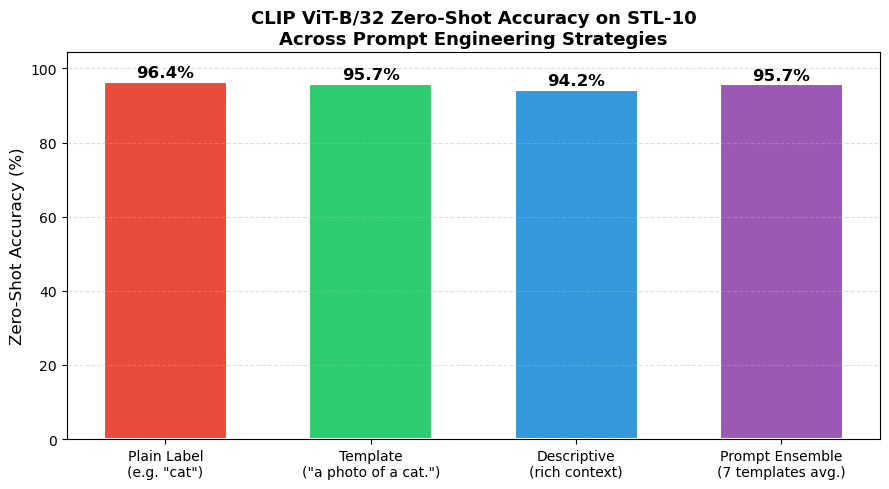

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

strategy_labels = {
    'plain': 'Plain Label\n(e.g. "cat")',
    'template': 'Template\n("a photo of a cat.")',
    'descriptive': 'Descriptive\n(rich context)',
    'ensemble': 'Prompt Ensemble\n(7 templates avg.)'
}
names = [strategy_labels[s] for s in strategies]
accs = [results[s]['accuracy'] * 100 for s in strategies]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

bars = ax.bar(names, accs, color=colors, width=0.6, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=12)
ax.set_title('CLIP ViT-B/32 Zero-Shot Accuracy on STL-10\nAcross Prompt Engineering Strategies',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(accs) + 8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/prompt_strategy_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Per-Class Accuracy Heatmap
Showing how each prompt strategy performs on individual STL-10 classes.

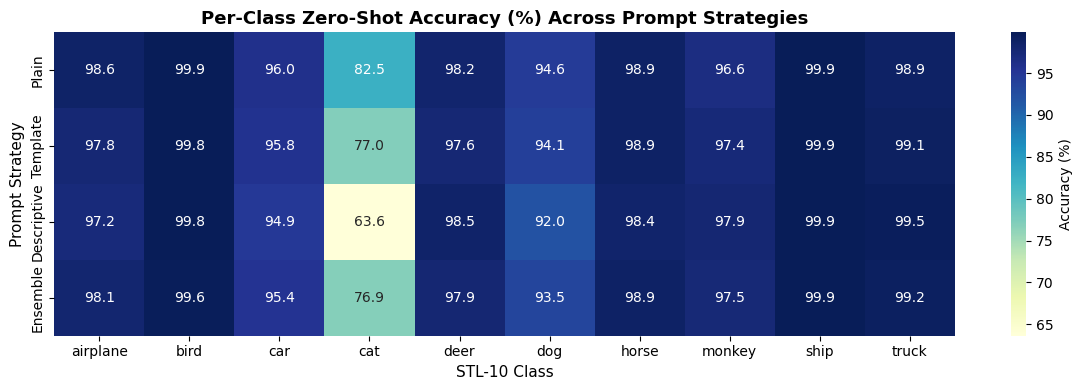

In [6]:
# Compute per-class accuracy for each strategy
per_class_accs = {}
for s in strategies:
    preds = results[s]['predictions']
    labels = results[s]['labels']
    class_acc = []
    for ci in range(len(class_names)):
        mask = labels == ci
        class_acc.append((preds[mask] == labels[mask]).mean() * 100 if mask.sum() > 0 else 0)
    per_class_accs[s] = class_acc

# Build heatmap matrix: rows = strategies, cols = classes
heatmap_data = np.array([per_class_accs[s] for s in strategies])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=[s.capitalize() for s in strategies],
            ax=ax, cbar_kws={'label': 'Accuracy (%)'})
ax.set_title('Per-Class Zero-Shot Accuracy (%) Across Prompt Strategies', fontsize=13, fontweight='bold')
ax.set_xlabel('STL-10 Class', fontsize=11)
ax.set_ylabel('Prompt Strategy', fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/per_class_accuracy_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

### Confusion Matrix — Best Prompt Strategy
Detailed error analysis for the highest-accuracy strategy.

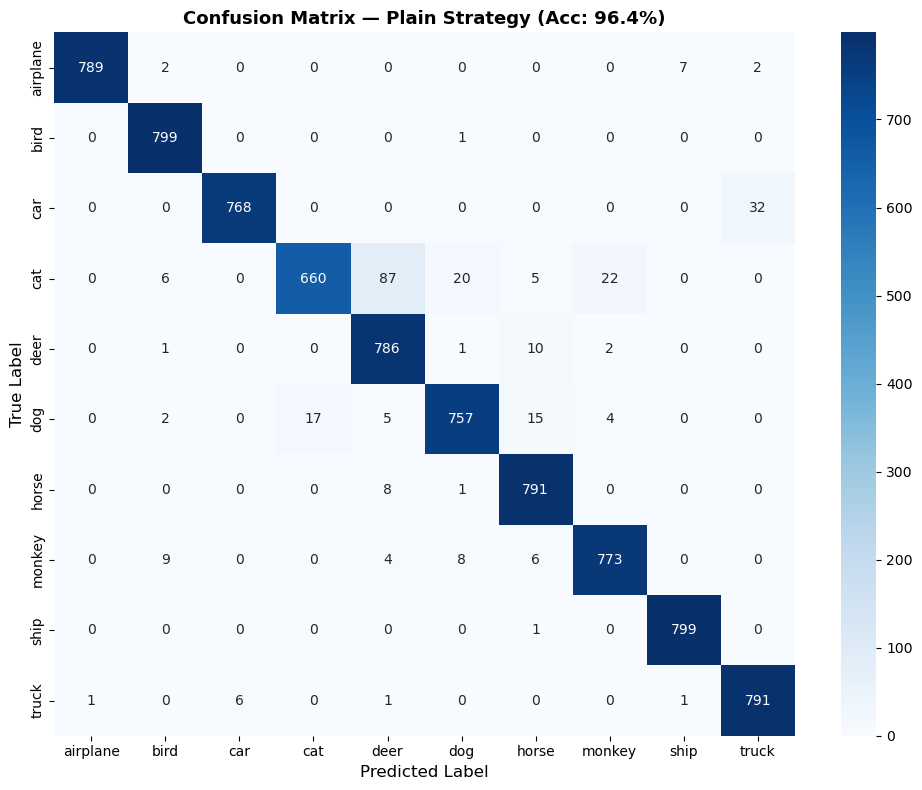

Best strategy: plain (96.41%)


In [7]:
from sklearn.metrics import confusion_matrix

# Pick the best strategy
best_strategy = max(results, key=lambda s: results[s]['accuracy'])
best_preds = results[best_strategy]['predictions']
best_labels = results[best_strategy]['labels']
best_acc = results[best_strategy]['accuracy']

cm = confusion_matrix(best_labels, best_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_strategy.capitalize()} Strategy (Acc: {best_acc*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/zeroshot_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Best strategy: {best_strategy} ({best_acc*100:.2f}%)')

### Sample Predictions Visualization
Showing 15 random test images with their true labels and CLIP zero-shot predictions.

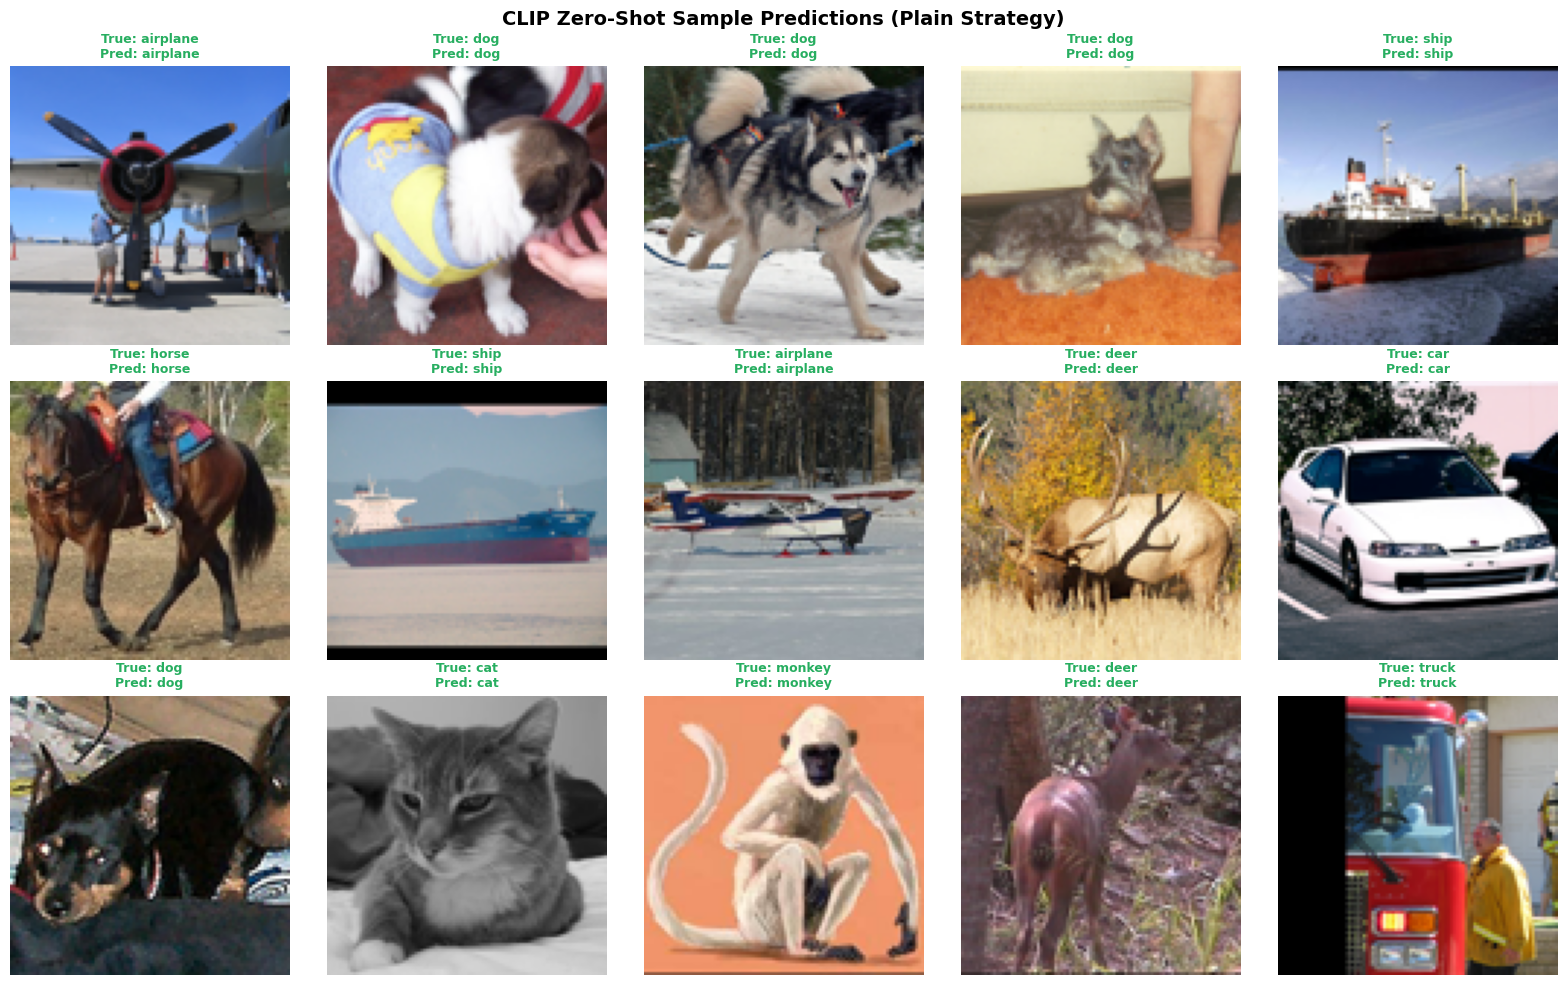

In [8]:
# Load raw dataset for clean RGB display
raw_dataset = load_stl10_dataset(root='../data', split='test', transform=None)

np.random.seed(42)
sample_indices = np.random.choice(len(raw_dataset), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img, true_label = raw_dataset[idx]
    pred_label = best_preds[idx]
    correct = pred_label == true_label
    
    axes[i].imshow(img)
    colour = '#27ae60' if correct else '#c0392b'
    axes[i].set_title(
        f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}',
        fontsize=9, fontweight='bold', color=colour
    )
    axes[i].axis('off')

fig.suptitle(f'CLIP Zero-Shot Sample Predictions ({best_strategy.capitalize()} Strategy)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/zeroshot_sample_predictions.png', bbox_inches='tight', dpi=300)
plt.show()

### Similarity Score Distribution
Visualising the distribution of CLIP cosine similarity scores for correct vs incorrect predictions.

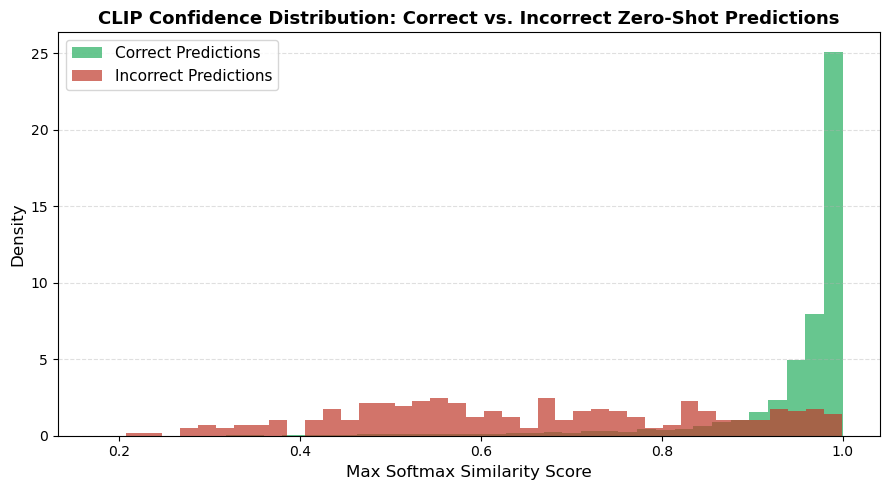

In [9]:
best_sims = results[best_strategy]['similarities']
# Get max similarity per sample (confidence)
max_sims = best_sims.max(axis=1)
correct_mask = best_preds == best_labels

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(max_sims[correct_mask], bins=40, alpha=0.7, color='#27ae60', label='Correct Predictions', density=True)
ax.hist(max_sims[~correct_mask], bins=40, alpha=0.7, color='#c0392b', label='Incorrect Predictions', density=True)
ax.set_xlabel('Max Softmax Similarity Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('CLIP Confidence Distribution: Correct vs. Incorrect Zero-Shot Predictions',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/zeroshot_confidence_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

### Discussion Questions & Empirical Analysis

**1. Why do contextual prompt templates improve zero-shot accuracy over plain class labels?**
- During CLIP’s contrastive pre-training on 400M web image–text pairs, the text encoder learns to match **full natural language captions**, not isolated words. When we use bare labels (e.g., `"cat"`), the text embedding falls outside the distribution of caption-like sentences the model was trained on.
- Template prompts like `"a photo of a cat."` align the input text closer to the **pre-training sentence distribution**, producing more discriminative embeddings that better correspond to natural image representations.

**2. Why does prompt ensemble further improve accuracy?**
- Averaging embeddings across multiple templates (e.g., `"a blurry photo of a ..."`, `"a close-up photo of a ..."`) creates a **more robust, centred text prototype** for each class. This smooths over idiosyncratic biases of individual templates, reducing sensitivity to any single phrasing.

**3. Which classes are easiest/hardest for CLIP zero-shot classification?**
- **Easy classes** (e.g., airplane, ship) tend to have highly distinctive visual and semantic features with few confusable alternatives.
- **Hard classes** (e.g., cat vs. dog, car vs. truck) share visual similarities or overlap in common co-occurrence contexts during pre-training, leading to higher inter-class confusion.

**4. How does CLIP’s zero-shot performance compare to supervised baselines?**
- CLIP ViT-B/32 achieves competitive accuracy on STL-10 **without seeing any training examples**, approaching or matching supervised ResNet baselines trained on STL-10 labelled data. This demonstrates the power of large-scale contrastive pre-training for transfer learning.